## Support Vector Machine
Immports and functions

In [1]:
import pandas as pd
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve
from tempfile import mkdtemp
from shutil import rmtree

# --- DE CUSTOM SELECTOR ---
class CorrelationTTestSelector(BaseEstimator, TransformerMixin):
    def __init__(self, corr_threshold=0.95, alpha=0.05):
        self.corr_threshold = corr_threshold
        self.alpha = alpha
        self.selected_indices_ = None
        
    def fit(self, X, y):
        X_df = pd.DataFrame(X)
        y_arr = np.array(y)
        
        # 1. Correlatie filter (verwijder redundante features)
        corr_matrix = X_df.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop_corr = [column for column in upper.columns if any(upper[column] > self.corr_threshold)]
        features_after_corr = [c for c in X_df.columns if c not in to_drop_corr]
        
        # 2. T-test met Bonferroni correctie (behou alleen significante features)
        features_after_ttest = []
        n_features = len(features_after_corr)
        for col in features_after_corr:
            group0 = X_df.loc[y_arr == 0, col]
            group1 = X_df.loc[y_arr == 1, col]
            if len(group0) > 0 and len(group1) > 0:
                _, p_value = ttest_ind(group0, group1, equal_var=False)
                if p_value <= (self.alpha / n_features):
                    features_after_ttest.append(col)
                
        self.selected_indices_ = features_after_ttest
        return self
        
    def transform(self, X, y=None):
        return X[:, self.selected_indices_]

# --- EVALUATIE FUNCTIE ---
def evaluate_model_on_test(clf, X_test, y_test, name="model"):
    y_pred = clf.predict(X_test)
    y_score = clf.predict_proba(X_test)[:, 1] if hasattr(clf, 'predict_proba') else clf.decision_function(X_test)

    print(f"--- Evaluation: {name} ---")
    print(classification_report(y_test, y_pred, zero_division=1))
    
    test_auc_pr = average_precision_score(y_test, y_score)
    print(f"AUC-PR: {test_auc_pr:.3f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    baseline = y_test.mean()
    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, lw=2, label=f'SVM (AUC-PR = {test_auc_pr:.2f})')
    plt.axhline(y=baseline, color='r', linestyle='--', label=f'Baseline ({baseline:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

In [2]:
with zipfile.ZipFile("ecg_data.zip","r") as zip_ref:
    zip_ref.extractall("ecg_data")

def load_data():
    this_directory = os.getcwd()
    data = pd.read_csv(os.path.join(this_directory, 'ecg_data/ecg_data.csv'), index_col=0)
    return data

raw_data = load_data()

X = raw_data.drop('label', axis=1)
Y = raw_data['label']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=4, stratify=Y)

In [4]:
cachedir = mkdtemp()

# Volledige Pipeline
svm_pipeline = Pipeline([
    ('var_filter', VarianceThreshold(threshold=0.01)),
    ('corr_ttest_filter', CorrelationTTestSelector(corr_threshold=0.95, alpha=0.05)),
    ('scaler', RobustScaler()),
    ('svm', SVC(probability=True, class_weight='balanced', random_state=42))
], memory=cachedir)

# Hyperparameter grids per kernel
param_distributions = [
    {
        'svm__kernel': ['rbf', 'sigmoid'],
        'svm__C': [0.1, 1, 10, 100],
        'svm__gamma': ['scale', 'auto', 0.1, 1]
    },
    {
        'svm__kernel': ['poly'],
        'svm__C': [0.1, 1, 10],
        'svm__degree': [2, 3]
    }
]

# Tuning met 3-fold cross-validation
random_search_svm = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=param_distributions,
    n_iter=20, 
    scoring='average_precision', 
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    verbose=2,
    n_jobs=1
)

print("Start training en tuning...")
random_search_svm.fit(x_train, y_train)

rmtree(cachedir)
print(f"Beste instellingen gevonden: {random_search_svm.best_params_}")

Start training en tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END ........svm__C=1, svm__gamma=scale, svm__kernel=rbf; total time= 2.2min
[CV] END ........svm__C=1, svm__gamma=scale, svm__kernel=rbf; total time= 2.5min
[CV] END ........svm__C=1, svm__gamma=scale, svm__kernel=rbf; total time= 2.2min
[CV] END .......svm__C=10, svm__gamma=scale, svm__kernel=rbf; total time=   0.9s
[CV] END .......svm__C=10, svm__gamma=scale, svm__kernel=rbf; total time=   0.5s
[CV] END .......svm__C=10, svm__gamma=scale, svm__kernel=rbf; total time=   0.4s
[CV] END ......svm__C=1, svm__gamma=0.1, svm__kernel=sigmoid; total time=   0.4s
[CV] END ......svm__C=1, svm__gamma=0.1, svm__kernel=sigmoid; total time=   0.4s
[CV] END ......svm__C=1, svm__gamma=0.1, svm__kernel=sigmoid; total time=   0.4s
[CV] END ........svm__C=0.1, svm__degree=3, svm__kernel=poly; total time=   0.4s
[CV] END ........svm__C=0.1, svm__degree=3, svm__kernel=poly; total time=   0.4s
[CV] END ........svm

--- Evaluation: Optimized SVM Pipeline ---
              precision    recall  f1-score   support

           0       0.88      0.73      0.80       137
           1       0.30      0.55      0.39        29

    accuracy                           0.70       166
   macro avg       0.59      0.64      0.60       166
weighted avg       0.78      0.70      0.73       166

AUC-PR: 0.459


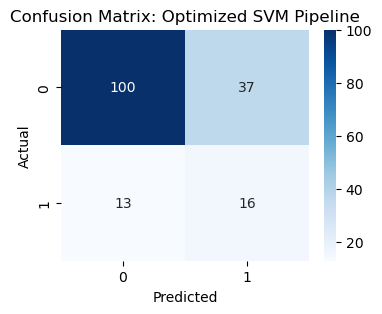

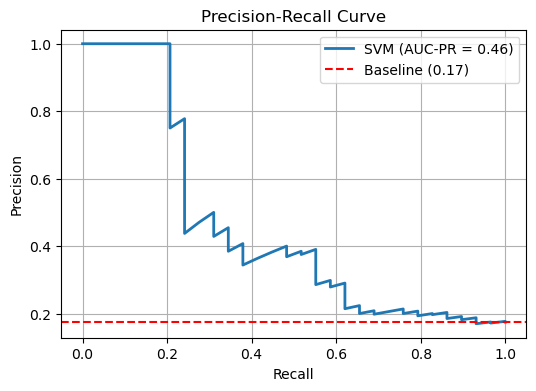

In [5]:
best_svm_model = random_search_svm.best_estimator_
evaluate_model_on_test(best_svm_model, x_test, y_test, name="Optimized SVM Pipeline")